In [1]:
import json
import re
from typing import Any, Dict, List

import dvc.api
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import HTML, display
from matplotlib import pyplot as plt

In [2]:
metrics_commits = {
    "CYFRAGOVPL/Llama-PLLuM-8B-instruct": "c9e5cdd13e9dfa0132091f748107d281968f1b6a",
    "speakleash/Bielik-11B-v2.2-Instruct": "3c8b0959adf5a6c89e71e0b9e7fba5f9c104bc78",
    "GPT-4o-mini": "84bd0e7d9e3f57e43d555694e798e6185b494730",
    "PLLUMGraph": "decf8340bfef0bebe1a806d83953b96bfaa795bf",
}

metrics_dicts = {k: dvc.api.metrics_show(rev=sha) for k, sha in metrics_commits.items()}

In [3]:
measuring_strategies = ["Ent_type", "Partial", "Strict", "Exact"]
values = {
    k: [v["total_f1"][s] for s in measuring_strategies]
    for k, v in metrics_dicts.items()
}

In [4]:
def plot_bar_grouped(
    x_labels: List[str], values: Dict[str, List[float]], ax_kwargs: Dict[str, Any] = {}
):
    x = np.arange(len(x_labels))  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout="constrained")

    for attribute, measurement in values.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3, fmt="%.2f")
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set(**ax_kwargs)
    ax.set_xticks(x + width, x_labels)
    ax.legend(loc="best")

    fig.show()

# 1. Overall F1 scores

PLLUMGraph achieved similar results to Bielik, which looks promising, but also suggests that Bielik has been heavily used.

/tmp/ipykernel_3395/3429667109.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


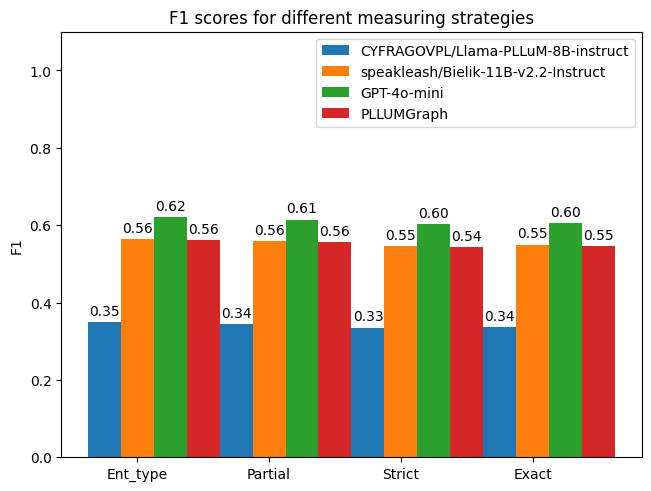

In [5]:
plot_bar_grouped(
    measuring_strategies,
    values,
    ax_kwargs={
        "ylabel": "F1",
        "title": "F1 scores for different measuring strategies",
        "ylim": (0, 1.1),
    },
)

In [6]:
total_found_objects = ["Subjects", "Predicates", "Objects", "Full_triples"]
values = {
    k: [
        v["total_found_strict_or_partial_percent"][s.lower()]
        for s in total_found_objects
    ]
    for k, v in metrics_dicts.items()
}

# 2. Successfuly detected parts of triples

Again - results quite close to Bielik

/tmp/ipykernel_3395/3429667109.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


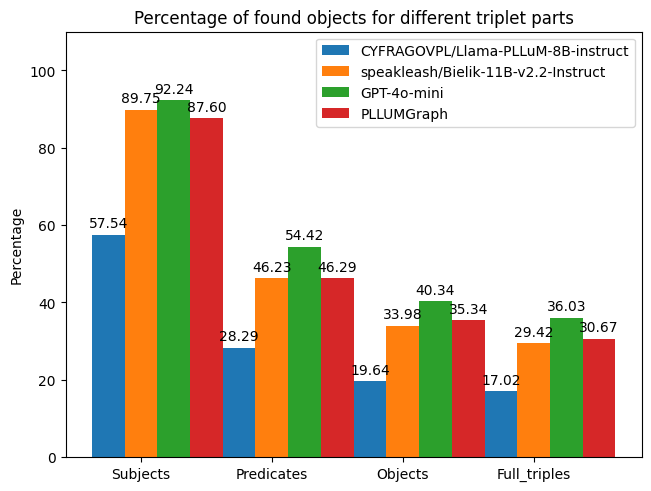

In [7]:
plot_bar_grouped(
    total_found_objects,
    values,
    ax_kwargs={
        "ylabel": "Percentage",
        "title": "Percentage of found objects for different triplet parts",
        "ylim": (0, 110),
    },
)

In [8]:
def get_extracted_relations(commit: str):
    with dvc.api.open("data/edc_baseline/cands.xml", rev=commit) as f:
        cands = f.read()
        # Parse the XML data
        soup = BeautifulSoup(cands, "xml")

        # Extract all gtriple elements
        cands = [gtriple.text for gtriple in soup.find_all("gtriple")]

    with dvc.api.open("data/edc_baseline/refs.xml", rev=commit) as f:
        refs = f.read()
        # Parse the XML data
        soup = BeautifulSoup(refs, "xml")

        # Extract all gtriple elements
        refs = [otriple.text for otriple in soup.find_all("otriple")]

    with dvc.api.open("data/edc_baseline/extracted_relations.json", rev=commit) as f:
        responses = json.loads(f.read())["responses"]

    return dict(cands=cands, refs=refs, responses=responses)


extracted_relations = {
    k: get_extracted_relations(v) for k, v in metrics_commits.items()
}

In [9]:
pattern = r"^.+\s\|\s.+\s\|\s.+$"


def is_valid_triple(triple: str):
    return bool(re.match(pattern, triple))

In [10]:
number_of_invalid_triples = {
    k: sum([not is_valid_triple(triple) for triple in v["cands"]])
    for k, v in extracted_relations.items()
}

In [11]:
number_of_invalid_triples

{'CYFRAGOVPL/Llama-PLLuM-8B-instruct': 6070,
 'speakleash/Bielik-11B-v2.2-Instruct': 601,
 'GPT-4o-mini': 308,
 'PLLUMGraph': 922}

In [12]:
def plot_bar_ungrouped(
    x_labels: List[str],
    values: List[float],
    ax_kwargs: Dict[str, Any] = {},
    xticks_kwargs: Dict[str, Any] = {},
):
    x = np.arange(len(x_labels))  # the label locations
    width = 0.25  # the width of the bars

    fig, ax = plt.subplots()

    rects = ax.bar(x, values, width)
    ax.bar_label(rects, padding=3, fmt="%.2f")

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set(**ax_kwargs)
    ax.set_xticks(x, x_labels, **xticks_kwargs)

    fig.show()

# 3. Number of invalid triples

Drastic improvement when counting invalid triples, when comparing baseline PLLUM and PLLUMGraph.

/tmp/ipykernel_3395/3878522688.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


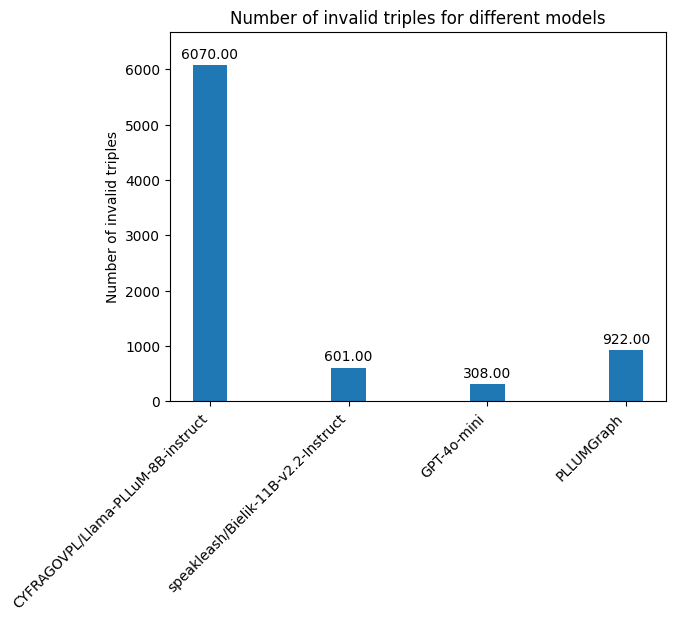

In [13]:
plot_bar_ungrouped(
    list(number_of_invalid_triples.keys()),
    list(number_of_invalid_triples.values()),
    ax_kwargs={
        "ylabel": "Number of invalid triples",
        "title": "Number of invalid triples for different models",
        "ylim": (0, max(number_of_invalid_triples.values()) * 1.1),
    },
    xticks_kwargs={"rotation": 45, "ha": "right"},
)

# 4. Invalid triples - deep dive

TBA

In [14]:
def show_invalid_responses(model):
    extracted_relations_pllum = pd.DataFrame(extracted_relations[model])
    extracted_relations_pllum["is_valid"] = extracted_relations_pllum.cands.apply(
        is_valid_triple
    )
    display(
        HTML(
            pd.DataFrame(
                extracted_relations_pllum[
                    extracted_relations_pllum.is_valid == False
                ].responses
            )
            .sample(50)
            .to_html()
        )
    )


show_invalid_responses("CYFRAGOVPL/Llama-PLLuM-8B-instruct")

,responses
1467,Nie udało mi się znaleźć żadnej relacji dla podanego tekstu.
12467,"[[Dan Smith, autor, piosenkę ""La Lune""], [Dan Smith, autor, piosenkę ""Better Love""]]"
256,"Nie ma relacji, którą można wyciągnąć z tego tekstu."
15212,"[[""Ľubomír Meszároš"", ""miejsce urodzenia"", ""Bratysława""], [""Ľubomír Meszároš"", ""zawód"", ""Piłkarz""]]"
4022,"Nie ma wystarczających informacji w tekście, aby wyciągnąć trójkę."
3878,"[[Jan IX OSB', 'zdobyta nagroda', 'Papież']"
8208,"Nie ma relacji, która łączy te dwa obiekty."
11964,"[[Skybus Airlines','siedziba', 'Columbus, w stanie Ohio']"
14050,"Nie ma żadnych trójek, które można wyciągnąć z tekstu."
3781,"[[Jessica Alba, zdobyta nagroda, Spike TV], [Jessica Alba, miejsce urodzenia, Pomonie], [Jessica Alba, zawód, Aktorka]]"


In [15]:
show_invalid_responses("speakleash/Bielik-11B-v2.2-Instruct")

,responses
10107,"[ ['Supertramp', 'typ', 'Album studyjny'] ]"
2634,"[['Jean-Claude Juncker', 'zawód', 'Premier'], ['Jean-Claude Juncker', 'członek', 'rządu']]"
14026,"[['Pat Robertson','miejsce urodzenia', 'Lexington'], ['Pat Robertson', 'zawód', 'Teleewangelista']]"
5468,"(['Meghna Naidu','miejsce urodzenia', 'Vijayawada'])"
14032,"['Nikołaj','miejsce urodzenia', 'Syn']]\n\n[['Mechanik: Czas zemsty', 'autor', 'Dolph Lundgren']]\n\n[['Mechanik: Czas zemsty', 'typ', 'Film']]\n\n[['Dolph Lundgren', 'zawód', 'Aktor']]\n\n[['Syn', 'rodzic', 'Nikołaj']]\n\n[['Nikołaj','ma dziecko', 'Syn']]\n\n[['Mechanik: Czas zemsty', 'lider postaci', 'Nikołaj']]\n\n[['Nikołaj', 'rodzaj postaci', 'Mechanik']]\n\n[['Dolph Lundgren', 'zawód', 'Aktor w filmie o zemście']]"
16141,"[['Seno', 'lokalizacja', 'Hiszpania']]\n[['Seno', 'liczba ludności', '45']]"
4423,"[['Franco Lucentini', 'zawód', 'Nieznany z kontekstu']]\n\nLepsza trójka, z uwzględnieniem najbardziej prawdopodobnych relacji:\n\n[['Franco Lucentini','miejsce urodzenia', 'Rzym']]"
9238,"[['D.W. Griffith', 'zawód', 'Reżyser']]\n\n[['D.W. Griffith', 'członek', 'Ku Klux Klan']]\n\n[['D.W. Griffith', 'z kraju', 'Stany Zjednoczone']]\n\n[['D.W. Griffith','miejsce urodzenia', 'LaGrange, Hrabstwo Oldham (Kentucky)']]\n\n[['D.W. Griffith', 'rok wydarzenia', '1875']]"
795,"[['August', 'zawód', 'Imperator'], ['August', 'zaliczenie', 'Bóg']]"
11040,"[['Karol Ludwik Napoleon Bonaparte','miejsce urodzenia', 'Rzym']]\n\nUzasadnienie: W tekście nie ma informacji o zawodzie ani dacie urodzenia, więc należy wybrać mniej bezpośrednio powiązaną relację. ""Rzym"" pojawia się jako miejsce urodzenia, więc ta relacja wydaje się najbardziej odpowiednia w kontekście dostępnych informacji.\n\nZwróć uwagę, że tekst kończy się na słowach ""ur."", więc nie ma pełnej daty urodzenia ani zawodu, które mogłyby utrudnić wybór relacji. Ponadto, w podanych przykładach również wybrano relacje oparte na miejscach (Quito, Buenos Aires, Rzym), co sugeruje, że w teście możemy spodziewać się trójek tego typu.\n\nDodatkowo, informacja o ""Rzymie"" pojawia się w tekście jako bezpośrednie określenie miejsca urodzenia, co czyni tę relację najbardziej pasującą spośród wszystkich możliwych kategorii, biorąc pod uwagę dostępne dane."


In [16]:
show_invalid_responses("GPT-4o-mini")

,responses
9991,"[['Led Zeppelin IV', 'typ', 'Album']]}"
7679,"[['Hrabstwo Grant', 'liczba ludności', '24682']]}"
11291,"[['Ramzan Paskajew', 'miejsce urodzenia', 'Taraz']]}"
12855,"[['Perenjori', 'lokalizacja', 'Australia']]]"
14201,"[['Bakers Hill', 'lokalizacja', 'Australia']]}"
4220,"[['Rosemary DeCamp', 'zawód', 'Aktor']]]"
10994,"[['Język arabela', 'typ', 'Język']]]"
3428,"[['Lawley Thembinkosi Fanteni', 'miejsce urodzenia', 'Kapsztad']]]"
1544,"[['Antonio Pribanić', 'zawód', 'Gracz']]\n\n"
3022,"[['Júlio Tavares', 'zawód', 'Zawodnik']]}"


In [17]:
show_invalid_responses("PLLUMGraph")

,responses
985,"[[Peter Ward, zawód, Piłkarz], [Peter Ward, miejsce pracy, Derby]]"
17056,"Otar Taktakiszwili, typ, Kompozytor"
11307,Nie ma możliwości wybrania jednej najbardziej prawdopodobnej trójki.
13607,"['Zamek Eureki', 'typ', 'Serial telewizyjny'] \n['Zamek Eureki', 'rok wydarzenia', '1989'] \n['Zamek Eureki', 'dla', 'dla dzieci'] \n['Zamek Eureki', 'gatunek', 'Serial'] \n['Eureeka','siedziba', 'Zamek Eureki'] \n['Zamek Eureki','ma', 'Eureekę'] \n['Eureka','ma', 'Zamek Eureki'] \n['Zamek Eureki', 'lokalizacja', 'Eureka'] \n\nWybieram:\n['Zamek Eureki', 'rok wydarzenia', '1989'] \n['Zamek Eureki', 'typ', 'Serial telewizyjny'] \n['Zamek Eureki', 'dla', 'dla dzieci'] \n['Zamek Eureki', 'gatunek', 'Serial'] \n['Zamek Eureki','ma', 'Eureekę'] \n\nPonieważ mam wybrać tylko jedną trójkę, wybieram:\n\n['Zamek Eureki', 'rok wydarzenia', '1989'] \n\nJest to najbardziej prawdopodobna relacja, ponieważ rok rozpoczęcia emisji serialu jest kluczową informacją, która definiuje jego istnienie w kontekście czasowym."
11557,"[[Monika Migała, z d. Gunia, miejsce urodzenia, Zgierz]]"
11776,"[[Kevin Johnson, miejsce urodzenia, Asbury Park, New Jersey]]"
3761,"[['Dalzell', 'lokalizacja', 'Illinois']]\n[['Dalzell', 'liczba ludności', '717 osób']]"
2919,"[[Silmarillion', 'autor', 'J.R.R.']"
14284,"[[Don Siegelman, właśc. Siegelman, miejsce pracy, Alabama]]"
8235,"[[Annunzio Paolo Mantovani, miejsce urodzenia, Tunbridge Wells, Kent]]"


In [23]:
import pickle


with dvc.api.open(
    "data/edc_baseline/graph_states.pkl", rev=metrics_commits["PLLUMGraph"], mode="rb"
) as f:
    graph_states = pickle.load(f)

len(graph_states)

17168

# 5. Conclusions for this part

Bielik and GPT-4o-mini have similar performance on the task. PLLUM shows significantly lower efficiency, probably because of its eagerness to refuse answering.

Empirically, it has been noticed that among models that were run locally on GPU (Bielik and PLLUM), PLLUM had faster inference time. It is therefore possible to apply efficient pipeline that utilizes PLLUM as a first model that attempts extracting relations, then delegate errors to a more capable model which may be instructed to correct errors after the predecessor. This may increase performance without referring to extremely large models, which has some benefits: lower carbon footprint, faster inference time.